<a href="https://colab.research.google.com/github/ajtony3000/automated-intraOT-anesthesia-delivery/blob/main/intraOT_anesthesia_delivery_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import math
import random
import sys

# --- 1. THE BRAIN (Your Logic) ---
class AnesthesiaAutomator:
    def __init__(self, age, weight, height, sex, baseline_hrv):
        self.weight = weight
        self.height = height
        self.sex = sex
        self.baseline_hrv = baseline_hrv

        # Schnider LBM Calc
        if sex.lower() == 'female':
            self.lbm = (1.07 * weight) - 148 * ((weight / height) ** 2)
        else:
            self.lbm = (1.1 * weight) - 128 * ((weight / height) ** 2)

        self.current_rate_ml_hr = 0.0
        self.start_time = time.time()
        self.last_adjustment_time = 0
        self.refractory_period = 10  # Reduced to 10s for faster demo visualization

    def get_base_maintenance_rate(self):
        # 10-8-6 Rule (Scaled to seconds for this fast demo)
        elapsed_sec = time.time() - self.start_time
        if elapsed_sec < 20: mg_kg_hr = 10
        elif elapsed_sec < 40: mg_kg_hr = 8
        else: mg_kg_hr = 6
        return (mg_kg_hr * self.weight) / 10

    def master_controller(self, inputs):
        # 1. KILL SWITCHES
        if inputs['EtCO2'] < 20: return 0.0, "CRITICAL: EtCO2 DROP", "RED"
        if inputs['SpO2'] < 90:
            if abs(inputs['SpO2_PR'] - inputs['HR']) < 15: return 0.0, "CRITICAL: HYPOXIA", "RED"
            else: return self.current_rate_ml_hr, "ARTIFACT: SpO2 Mismatch", "YELLOW"
        if inputs['MAP'] < 55: return 0.0, "CRITICAL: HYPOTENSION", "RED"

        # 2. ARTIFACT VETO
        acc_mag = math.sqrt(inputs['acc_x']**2 + inputs['acc_y']**2 + inputs['acc_z']**2)
        if acc_mag > 1.2:
            if inputs['TOF_Count'] == 0: return self.current_rate_ml_hr, "ARTIFACT: Motion (TOF=0)", "YELLOW"
            else: return self.current_rate_ml_hr, "WARNING: Patient Moving", "ORANGE"

        # 3. DOSING LOGIC
        base_rate = self.get_base_maintenance_rate()
        target_rate = base_rate
        msg = "Stable"

        # Pain Check (HRV)
        hrv_drop = (self.baseline_hrv - inputs['RMSSD']) / self.baseline_hrv
        can_adjust = (time.time() - self.last_adjustment_time) > self.refractory_period

        if hrv_drop > 0.30:
            if can_adjust:
                target_rate = base_rate * 1.3
                self.last_adjustment_time = time.time()
                msg = "PAIN: Dose +30%"
            else:
                target_rate = self.current_rate_ml_hr # Hold high
                msg = "PAIN: Waiting (Hysteresis)"

        self.current_rate_ml_hr = target_rate
        return target_rate, msg, "GREEN"

# --- 2. THE PATIENT (Synthetic Data Generator) ---
class VirtualPatient:
    def __init__(self):
        # Initial Vitals
        self.vitals = {
            "HR": 75.0, "SpO2": 99.0, "SpO2_PR": 75.0, "MAP": 85.0,
            "EtCO2": 38.0, "RMSSD": 50.0, "BIS": 50.0,
            "acc_x": 0.0, "acc_y": 0.0, "acc_z": 1.0, "TOF_Count": 0,
            "CVP": 10, "PCWP": 12
        }
        self.baseline_hrv = 50.0

    def update(self, event_type=None):
        # 1. Natural Drift (Brownian Motion)
        self.vitals["HR"] += random.uniform(-1, 1)
        self.vitals["MAP"] += random.uniform(-0.5, 0.5)
        self.vitals["SpO2"] = min(100, self.vitals["SpO2"] + random.uniform(-0.1, 0.1))
        self.vitals["RMSSD"] += random.uniform(-2, 2)

        # Keep PR synced with HR unless artifact
        self.vitals["SpO2_PR"] = self.vitals["HR"] + random.uniform(-1, 1)

        # 2. Inject Events
        if event_type == "PAIN":
            self.vitals["HR"] += 2.0  # Rapid rise
            self.vitals["RMSSD"] -= 5.0 # Rapid drop
            self.vitals["MAP"] += 1.0

        elif event_type == "MOTION":
            self.vitals["acc_x"] = random.uniform(0.8, 1.5)
            self.vitals["SpO2"] = random.uniform(85, 95) # Fake drop
            self.vitals["SpO2_PR"] = 140 # Fake tachycardia

        elif event_type == "HYPOXIA":
            self.vitals["SpO2"] -= 2.0 # Fast drop
            self.vitals["HR"] += 1.0

        elif event_type == "RESET":
            self.vitals["acc_x"] = 0.0
            self.vitals["acc_y"] = 0.0

        # Clamp values to realistic ranges
        self.vitals["RMSSD"] = max(10, self.vitals["RMSSD"])
        return self.vitals

# --- 3. THE SIMULATION LOOP ---
def run_realtime_simulation():
    # Setup
    automator = AnesthesiaAutomator(45, 65, 160, 'female', baseline_hrv=50)
    patient = VirtualPatient()

    print(f"{'TIME':<5} | {'EVENT':<15} | {'HR':<5} | {'SpO2':<5} | {'HRV':<5} | {'ACC':<5} | {'PUMP (mL/hr)':<15} | {'STATUS'}")
    print("-" * 100)

    start_sim = time.time()

    try:
        while True:
            elapsed = int(time.time() - start_sim)
            current_event = None

            # --- SCENARIO SCRIPT ---
            if 10 <= elapsed < 20: current_event = "PAIN"      # T=10s: Surgeon cuts
            elif 30 <= elapsed < 35: current_event = "MOTION"  # T=30s: Table bump
            elif elapsed == 35: current_event = "RESET"        # T=35s: Motion stops
            elif elapsed > 50: current_event = "HYPOXIA"       # T=50s: Airway fails

            # 1. Get New Data
            inputs = patient.update(current_event)
            acc_total = math.sqrt(inputs['acc_x']**2 + inputs['acc_y']**2 + inputs['acc_z']**2)

            # 2. Run Brain
            rate, msg, color = automator.master_controller(inputs)

            # 3. Visuals
            # We use simple formatting to simulate a dashboard
            row = f"{elapsed}s".ljust(5) + " | "
            row += f"{current_event if current_event else '---'}".ljust(15) + " | "
            row += f"{int(inputs['HR'])}".ljust(5) + " | "
            row += f"{int(inputs['SpO2'])}%".ljust(5) + " | "
            row += f"{int(inputs['RMSSD'])}".ljust(5) + " | "
            row += f"{acc_total:.2f}g".ljust(5) + " | "
            row += f"{rate:.1f}".ljust(15) + " | "
            row += f"{msg}"

            print(row)

            # Wait 1 second (Real Time)
            time.sleep(1)

    except KeyboardInterrupt:
        print("\n--- SIMULATION STOPPED BY USER ---")

# Run it
run_realtime_simulation()

TIME  | EVENT           | HR    | SpO2  | HRV   | ACC   | PUMP (mL/hr)    | STATUS
----------------------------------------------------------------------------------------------------
0s    | ---             | 75    | 98%   | 51    | 1.00g | 65.0            | Stable
1s    | ---             | 75    | 99%   | 52    | 1.00g | 65.0            | Stable
2s    | ---             | 74    | 98%   | 51    | 1.00g | 65.0            | Stable
3s    | ---             | 74    | 98%   | 51    | 1.00g | 65.0            | Stable
4s    | ---             | 73    | 98%   | 52    | 1.00g | 65.0            | Stable
5s    | ---             | 73    | 98%   | 54    | 1.00g | 65.0            | Stable
6s    | ---             | 74    | 98%   | 54    | 1.00g | 65.0            | Stable
7s    | ---             | 75    | 98%   | 53    | 1.00g | 65.0            | Stable
8s    | ---             | 75    | 99%   | 52    | 1.00g | 65.0            | Stable
9s    | ---             | 74    | 98%   | 53    | 1.00g | 65.0       

╔══════════════════════════════════════════════════════════════╗
║   ANESTHESIA AI: SURGICAL AUTOMATION PROTOCOL                ║
╠══════════════════════════════════════════════════════════════╣
║  PATIENT: 45F | 65kg | LBM: 45.1kg                      ║
║  INDUCTION BOLUS (T=0): 8.12 mL (Administered)             ║
╚══════════════════════════════════════════════════════════════╝

Time: T+239s  |  Event: HYPOXIA
┌──────────────┬──────────────┬──────────────┬─────────────────┐
│      HR      │     SpO2     │  HRV (Pain)  │   PUMP RATE     │
│   229 bpm    │     -246%      │     012 ms    │   000.0 mL/hr    │
└──────────────┴──────────────┴──────────────┴─────────────────┘
 STATUS: [RED] CRITICAL: HYPOXIA


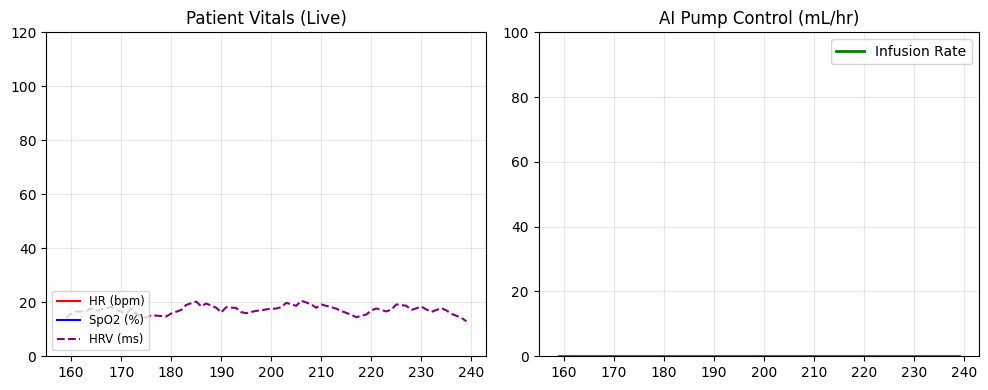

In [ ]:
import time
import math
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# ==========================================
# 1. THE BRAIN: ANESTHESIA CONTROLLER
# ==========================================
class AnesthesiaAutomator:
    def __init__(self, age, weight, height, sex, baseline_hrv):
        self.weight = weight
        self.height = height
        self.sex = sex
        self.baseline_hrv = baseline_hrv

        # Schnider LBM Calc
        if sex.lower() == 'female':
            self.lbm = (1.07 * weight) - 148 * ((weight / height) ** 2)
        else:
            self.lbm = (1.1 * weight) - 128 * ((weight / height) ** 2)

        self.current_rate_ml_hr = 0.0
        self.start_time = None
        self.last_adjustment_time = 0
        self.refractory_period = 10 # Shortened for demo speed
        self.bolus_given = False

    def calculate_induction(self):
        """Calculates the initial 'Fill the Tank' dose"""
        # 1.8 mg/kg LBM is standard for induction
        bolus_mg = 1.8 * self.lbm
        bolus_ml = bolus_mg / 10 # 1% Propofol (10mg/mL)
        return round(bolus_ml, 2)

    def get_base_maintenance_rate(self):
        # 10-8-6 Rule (Scaled to seconds for fast demo)
        elapsed_sec = time.time() - self.start_time
        if elapsed_sec < 20: mg_kg_hr = 10
        elif elapsed_sec < 40: mg_kg_hr = 8
        else: mg_kg_hr = 6
        return (mg_kg_hr * self.weight) / 10

    def master_controller(self, inputs):
        if self.start_time is None: self.start_time = time.time()

        # --- KILL SWITCHES ---
        if inputs['EtCO2'] < 20: return 0.0, "CRITICAL: EtCO2 DROP", "red"
        if inputs['SpO2'] < 90:
            if abs(inputs['SpO2_PR'] - inputs['HR']) < 15: return 0.0, "CRITICAL: HYPOXIA", "red"
            else: return self.current_rate_ml_hr, "ARTIFACT: SpO2 Mismatch", "orange"
        if inputs['MAP'] < 55: return 0.0, "CRITICAL: HYPOTENSION", "red"

        # --- ARTIFACT VETO ---
        acc_mag = math.sqrt(inputs['acc_x']**2 + inputs['acc_y']**2 + inputs['acc_z']**2)
        if acc_mag > 1.2:
            return self.current_rate_ml_hr, "ARTIFACT: Motion Detected", "orange"

        # --- DOSING LOGIC ---
        base_rate = self.get_base_maintenance_rate()
        target_rate = base_rate
        msg = "Stable Maintenance"

        # Pain Check (HRV)
        hrv_drop = (self.baseline_hrv - inputs['RMSSD']) / self.baseline_hrv
        can_adjust = (time.time() - self.last_adjustment_time) > self.refractory_period

        if hrv_drop > 0.30:
            if can_adjust:
                target_rate = base_rate * 1.3
                self.last_adjustment_time = time.time()
                msg = "PAIN: Dose +30%"
            else:
                target_rate = self.current_rate_ml_hr
                msg = "PAIN: Wait (Hysteresis)"

        self.current_rate_ml_hr = target_rate
        return target_rate, msg, "green"

# ==========================================
# 2. THE PATIENT: VIRTUAL SIMULATOR
# ==========================================
class VirtualPatient:
    def __init__(self):
        self.vitals = {
            "HR": 75.0, "SpO2": 99.0, "SpO2_PR": 75.0, "MAP": 85.0,
            "EtCO2": 38.0, "RMSSD": 50.0, "BIS": 50.0,
            "acc_x": 0.0, "acc_y": 0.0, "acc_z": 1.0, "TOF_Count": 0
        }

    def update(self, event_type=None):
        # Natural Drift
        self.vitals["HR"] += random.uniform(-1, 1)
        self.vitals["MAP"] += random.uniform(-0.5, 0.5)
        self.vitals["SpO2"] = min(100, self.vitals["SpO2"] + random.uniform(-0.1, 0.1))
        self.vitals["RMSSD"] += random.uniform(-2, 2)
        self.vitals["SpO2_PR"] = self.vitals["HR"] + random.uniform(-1, 1)

        # Inject Events
        if event_type == "PAIN":
            self.vitals["HR"] += 1.5; self.vitals["RMSSD"] -= 4.0
        elif event_type == "MOTION":
            self.vitals["acc_x"] = random.uniform(0.8, 1.5)
            self.vitals["SpO2"] = random.uniform(85, 95) # Fake drop
        elif event_type == "HYPOXIA":
            self.vitals["SpO2"] -= 2.5; self.vitals["HR"] += 1.0
        elif event_type == "RESET":
            self.vitals["acc_x"] = 0.0; self.vitals["SpO2"] = 99.0

        self.vitals["RMSSD"] = max(10, self.vitals["RMSSD"])
        return self.vitals

# ==========================================
# 3. THE UI: REAL-TIME DASHBOARD
# ==========================================
def run_dashboard_simulation():
    # Setup
    automator = AnesthesiaAutomator(45, 65, 160, 'female', baseline_hrv=50)
    patient = VirtualPatient()

    # Calculate Bolus ONCE at start
    bolus_ml = automator.calculate_induction()

    # Data Storage for Graphing
    history = {
        "time": [], "hr": [], "spo2": [], "hrv": [], "pump": []
    }

    start_sim = time.time()

    try:
        while True:
            elapsed = int(time.time() - start_sim)

            # --- SCENARIO SCRIPT ---
            event = None
            if 10 <= elapsed < 20: event = "PAIN"
            elif 30 <= elapsed < 35: event = "MOTION"
            elif elapsed == 35: event = "RESET"
            elif elapsed > 50: event = "HYPOXIA"

            # Update System
            inputs = patient.update(event)
            rate, msg, status_color = automator.master_controller(inputs)

            # Store Data (Keep last 60 seconds)
            history["time"].append(elapsed)
            history["hr"].append(inputs["HR"])
            history["spo2"].append(inputs["SpO2"])
            history["hrv"].append(inputs["RMSSD"])
            history["pump"].append(rate)

            if len(history["time"]) > 60:
                for k in history: history[k].pop(0)

            # --- RENDER UI (Clear & Redraw) ---
            clear_output(wait=True)

            # 1. Header / Bolus Info
            print(f"╔══════════════════════════════════════════════════════════════╗")
            print(f"║   ANESTHESIA AI: SURGICAL AUTOMATION PROTOCOL                ║")
            print(f"╠══════════════════════════════════════════════════════════════╣")
            print(f"║  PATIENT: 45F | 65kg | LBM: {automator.lbm:.1f}kg                      ║")
            print(f"║  INDUCTION BOLUS (T=0): {bolus_ml} mL (Administered)             ║")
            print(f"╚══════════════════════════════════════════════════════════════╝")

            # 2. Live Vitals Table
            print(f"\nTime: T+{elapsed}s  |  Event: {event if event else 'Stable'}")
            print(f"┌──────────────┬──────────────┬──────────────┬─────────────────┐")
            print(f"│      HR      │     SpO2     │  HRV (Pain)  │   PUMP RATE     │")
            print(f"│   {int(inputs['HR']):03d} bpm    │     {int(inputs['SpO2']):02d}%      │     {int(inputs['RMSSD']):03d} ms    │   {rate:05.1f} mL/hr    │")
            print(f"└──────────────┴──────────────┴──────────────┴─────────────────┘")

            # 3. Status Message
            print(f" STATUS: [{status_color.upper()}] {msg}")

            # 4. Dynamic Graphs
            plt.figure(figsize=(10, 4))

            # Left Plot: Vitals
            plt.subplot(1, 2, 1)
            plt.plot(history["time"], history["hr"], label="HR (bpm)", color="red")
            plt.plot(history["time"], history["spo2"], label="SpO2 (%)", color="blue")
            plt.plot(history["time"], history["hrv"], label="HRV (ms)", color="purple", linestyle="--")
            plt.title("Patient Vitals (Live)")
            plt.ylim(0, 120)
            plt.grid(True, alpha=0.3)
            plt.legend(loc='lower left', fontsize='small')

            # Right Plot: Pump Output
            plt.subplot(1, 2, 2)
            plt.plot(history["time"], history["pump"], label="Infusion Rate", color="green", linewidth=2)
            plt.fill_between(history["time"], history["pump"], color="green", alpha=0.1)
            plt.title("AI Pump Control (mL/hr)")
            plt.ylim(0, max(100, max(history["pump"])+10))
            plt.grid(True, alpha=0.3)
            plt.legend(loc='upper right')

            plt.tight_layout()
            plt.show()

            time.sleep(1) # Refresh rate

    except KeyboardInterrupt:
        print("Simulation Stopped.")

# Run it
run_dashboard_simulation()
